In [2]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
def root_hist_to_pyhist(th1d, colore, llabel, ls):
    n_bins = th1d.GetNbinsX()
    x_edges = [th1d.GetBinLowEdge(i+1) for i in range(n_bins)]
    x_edges.append(th1d.GetBinLowEdge(n_bins) + th1d.GetBinWidth(n_bins))
    bin_contents = [th1d.GetBinContent(i+1) for i in range(n_bins)]
    bin_errors = [th1d.GetBinError(i+1) for i in range(n_bins)]
    bin_centers =[th1d.GetBinCenter(i+1) for i in range(n_bins)]
    x_bin_errors=[th1d.GetBinWidth(i+1)/2 for i in range(n_bins)]

    
    # Creazione step per linee orizzontali
    x_step = np.repeat(x_edges, 2)[1:-1]
    y_step = np.repeat(bin_contents, 2)
    
    # Aggiunta linee verticali agli estremi
    x_step = np.insert(x_step, 0, x_edges[0])
    y_step = np.insert(y_step, 0, 0)  # parte dal basso
    x_step = np.append(x_step, x_edges[-1])
    y_step = np.append(y_step, 0)     # torna a 0 alla fine
    
    plt.step(x_step, y_step, where='mid', linewidth=2, color=colore, label=llabel, ls = ls)
    
    #plt.errorbar(bin_centers,bin_contents,xerr=x_bin_errors,yerr=bin_errors, fmt='o', color=colore, label=llabel, markersize=1)

    #plt.ylim(0, max(bin_contents)*1.1)

In [1]:
planeCL = 'IND2'
plane = 'ind2'
remote_host = 'icarusgpvm06'
remote_path = '/exp/icarus/data/users/nsommagg/'
remote_file_0 = f'PROVA_{planeCL}_MULT.root'
remote_file_1 = f'PDF_{planeCL}_NEW_MC.root'
remote_file_2 = f'PROVA_{planeCL}_MULT_WMCUT.root'
local_path = '~/Desktop/NicolaICARUS/PID/selection_newPID/check_pdfs/'

In [2]:
!scp {remote_host}:{remote_path}{remote_file_0} {local_path}
!scp {remote_host}:{remote_path}{remote_file_1} {local_path}
!scp {remote_host}:{remote_path}{remote_file_2} {local_path}

PROVA_IND2_MULT.root                          100%  685KB   5.3MB/s   00:00    
PDF_IND2_NEW_MC.root                          100%  698KB   4.9MB/s   00:00    
PROVA_IND2_MULT_WMCUT.root                    100%  682KB   7.7MB/s   00:00    


In [ ]:
!scp {remote_host}:{remote_path}dump_dedx_debug.txt {local_path}/dump_dedx_debug_mult.txt

In [ ]:
df_0 = pd.read_csv("dump_dedx_debug_mult.txt", sep=r"\s+", header=None, names=["class", "rr", "dedx", "wmcut"])
df_1 = pd.read_csv("dump_dedx_debug.txt", sep=r"\s+", header=None, names=["class", "rr", "dedx", "wmcut"])

In [ ]:
print(df_0.shape[0])
print(df_0[df_0['wmcut']==1].shape[0])
print(df_0[(df_0['wmcut']==1) & (df_0['dedx']>1.)].shape[0])

In [23]:
rr = 1.5
file_0 = ROOT.TFile.Open(f'{remote_file_0}','READ')
file_1 = ROOT.TFile.Open(f'{remote_file_1}','READ')
file_2 = ROOT.TFile.Open(f'{remote_file_2}','READ')

In [30]:
particle_a = 'muon_class1'
h_0a = file_0.Get(f'{particle_a}/{rr}/dEdx_{plane}_rr_{rr}')
h_1a = file_1.Get(f'{particle_a}/{rr}/dEdx_{plane}_rr_{rr}')
h_2a = file_2.Get(f'{particle_a}/{rr}/dEdx_{plane}_rr_{rr}')

In [ ]:
particle_b = 'muon_class1'
h_0b = file_0.Get(f'{particle_b}/{rr}/dEdx_{plane}_rr_{rr}')
h_1b = file_1.Get(f'{particle_b}/{rr}/dEdx_{plane}_rr_{rr}')
h_2b = file_2.Get(f'{particle_b}/{rr}/dEdx_{plane}_rr_{rr}')

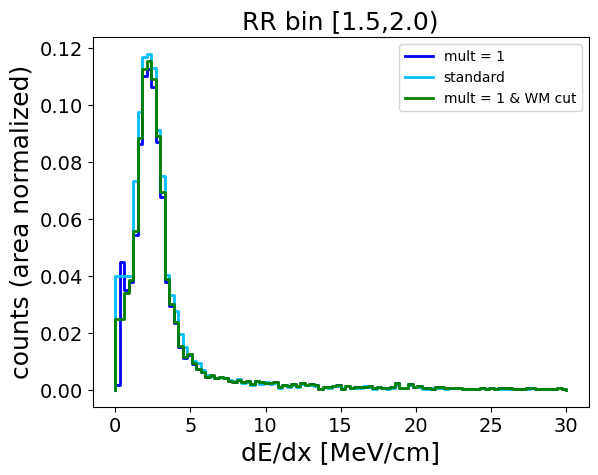

In [31]:
root_hist_to_pyhist(h_0a,'blue',r'mult = 1','-')
root_hist_to_pyhist(h_1a,'deepskyblue',r'standard','-')
root_hist_to_pyhist(h_2a,'green',r'mult = 1 & WM cut','-')
plt.xlabel('dE/dx [MeV/cm]',fontsize=18)
plt.ylabel('counts (area normalized)',fontsize=18)
plt.title(f'RR bin [{rr:.1f},{rr+0.5:.1f})',fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(loc='best',fontsize=10)
plt.show()

In [ ]:
plt.hist(df_0[(df_0['rr'] < 1.5) & (df_0['rr'] >= 1.) & (df_0['class']==2)]['dedx'], bins=100, range=(0,30), histtype='step', density=True, lw=2, label = 'all mult1')
plt.hist(df_0[(df_0['rr'] < 1.5) & (df_0['rr'] >= 1.) & (df_0['class']==2) & (df_0['wmcut']==0)]['dedx'], bins=100, range=(0,30), histtype='step', density=True, lw=2, label = 'WM cut mult1', ls = '--')
plt.hist(df_1[(df_1['rr'] < 1.5) & (df_1['rr'] >= 1.) & (df_1['class']==2)]['dedx'], bins=100, range=(0,30), histtype='step', density=True, lw=2, label = 'all', ls = '-.')
plt.xlabel('dE/dx [MeV/cm]',fontsize=18)
plt.ylabel('counts (area normalized)',fontsize=18)
plt.title(f'RR bin [{rr-0.5:.1f},{rr:.1f})',fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(loc = 'best', fontsize=12)
plt.show()